<a href="https://colab.research.google.com/github/un1u3/ml-labs/blob/main/fusemachines-2026/phase3/assignment4/Assignment3_NER_CustomerSupport.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3: End to End Named Entity Recognition (NER) for Customer Support Ticket Analysis

## Objectives
In this assignment I am building a full pipeline for Named Entity Recognition (NER). I will use customer support tickets as the motivation, but I am working with the standard CoNLL 2003 dataset as a stand in, and the goal is to pull out entities like people, organizations, and locations.

## Learning Outcomes
By the end of this notebook I should be able to:
1. Explain the basic idea behind sequence labeling and NER.
2. Run some exploratory data analysis on text data and look at how tokens and entities are distributed.
3. Build word level and contextual features that work well for a sequence model.
4. Train and evaluate a Conditional Random Field (CRF) model.
5. Read the model's results, look into where it makes mistakes, and connect the metrics back to what they would actually mean for a customer support team.

Setup: first let's make sure the libraries we need are installed. Run the cell below.


In [ ]:
!pip install datasets scikit-learn sklearn-crfsuite matplotlib -q


## 1. Introduction to Named Entity Recognition (NER) and CoNLL 2003

### What is Named Entity Recognition (NER)?
NER is part of the broader task of Information Extraction in NLP. The idea is simple: find named entities in unstructured text and sort them into categories such as person names, organizations, locations, medical codes, time expressions, quantities, and so on.

### Why CoNLL 2003?
The CoNLL 2003 dataset is one of the most commonly used benchmarks for NER. It's built from news wire articles and is a solid starting point for learning sequence labeling. Even though it comes from news text, training on it shows how the same kind of system could pick out client names or branch locations from real customer support tickets.

### Entity Labels in CoNLL 2003
The dataset tags things using the IOB (Inside, Outside, Beginning) format, with these entity types:
* PER: Person (e.g., John Doe)
* LOC: Location (e.g., London, Mt. Everest)
* ORG: Organization (e.g., United Nations, Google)
* MISC: Miscellaneous (e.g., nationalities, events like the World Cup)
* O: Outside of any named entity (just a regular word)


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from collections import Counter
from sklearn.metrics import classification_report
import sklearn_crfsuite
from sklearn_crfsuite import metrics

# Set matplotlib style for clean visualiztions
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## Task 1: Text Preprocessing and Exploratory Data Analysis (EDA)

### What I'm doing here
First I load the CoNLL 2003 dataset and take a look at how it's structured, then pull out the label names. After that I run some EDA to get a feel for word distribution, sentence lengths, and how the entity types are spread out.

### Why this matters
Before jumping into modeling, it helps to understand the shape of the data. Knowing things like vocabulary size, how long sentences tend to be, and how imbalanced the classes are (most words are just tagged 'O') helps in designing better features and picking the right evaluation metrics later on.

### Sequence Labeling and Tokenization
Regular text classification gives one label to a whole sentence (like positive or negative). Sequence labeling is different, it assigns a label to every single token in the sentence. Tokenization is what splits the text into those tokens in the first place, and if that step goes wrong, the entity boundaries end up wrong too.


In [ ]:
from datasets import load_dataset

dataset = load_dataset("eriktks/conll2003", revision="convert/parquet")
print(dataset)

ner_feature = dataset['train'].features['ner_tags'].feature
label_names = ner_feature.names
print(f"\nEntity Labels: {label_names}")

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})

Entity Labels: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']


### Looking at a Sample Sentence
Let's take one sentence from the training set and see how each token lines up with its NER label.


In [ ]:
# Fetch a sample sentence
sample_idx = 4
sample_tokens = dataset['train'][sample_idx]['tokens']
sample_ner_ids = dataset['train'][sample_idx]['ner_tags']

# Convert label IDs back to human-readable string labels
sample_ner_labels = [label_names[tag] for tag in sample_ner_ids]

print(f"{'Token':<15} | {'NER Tag':<10}")
print("-" * 30)
for token, label in zip(sample_tokens, sample_ner_labels):
    print(f"{token:<15} | {label:<10}")


Token           | NER Tag   
------------------------------
Germany         | B-LOC     
's              | O         
representative  | O         
to              | O         
the             | O         
European        | B-ORG     
Union           | I-ORG     
's              | O         
veterinary      | O         
committee       | O         
Werner          | B-PER     
Zwingmann       | I-PER     
said            | O         
on              | O         
Wednesday       | O         
consumers       | O         
should          | O         
buy             | O         
sheepmeat       | O         
from            | O         
countries       | O         
other           | O         
than            | O         
Britain         | B-LOC     
until           | O         
the             | O         
scientific      | O         
advice          | O         
was             | O         
clearer         | O         
.               | O         


### Exploratory Data Analysis (EDA)
Now let's calculate some basic statistics on the training set so we understand what we're working with.


In [ ]:
# Calculate dataset statistics
train_sentences = dataset['train']['tokens']
val_sentences = dataset['validation']['tokens']
test_sentences = dataset['test']['tokens']

# Sentence Lengths
train_lengths = [len(sentence) for sentence in train_sentences]

# Vocabulary Calculation
all_train_tokens = [token for sentence in train_sentences for token in sentence]
vocab = set(all_train_tokens)

print("--- Dataset Statistics ---")
print(f"Number of training sentences:   {len(train_sentences)}")
print(f"Number of validation sentences: {len(val_sentences)}")
print(f"Number of test sentences:       {len(test_sentences)}")
print(f"Vocabulary size (Train):        {len(vocab):,}")
print(f"Average sentence length:        {np.mean(train_lengths):.2f} tokens")
print(f"Maximum sentence length:        {np.max(train_lengths)} tokens")
print(f"Minimum sentence length:        {np.min(train_lengths)} tokens")


--- Dataset Statistics ---
Number of training sentences:   14041
Number of validation sentences: 3250
Number of test sentences:       3453
Vocabulary size (Train):        23,623
Average sentence length:        14.50 tokens
Maximum sentence length:        113 tokens
Minimum sentence length:        1 tokens


### Visualizing the Data

I'll use matplotlib to plot three things about the data:
1. Sentence Length Histogram: to see whether sentences tend to be short or long.
2. Top Word Frequencies: to see which words show up most often (usually punctuation and stop words).
3. Entity Label Distribution: to get a sense of the imbalance between 'O' tags and actual named entities.


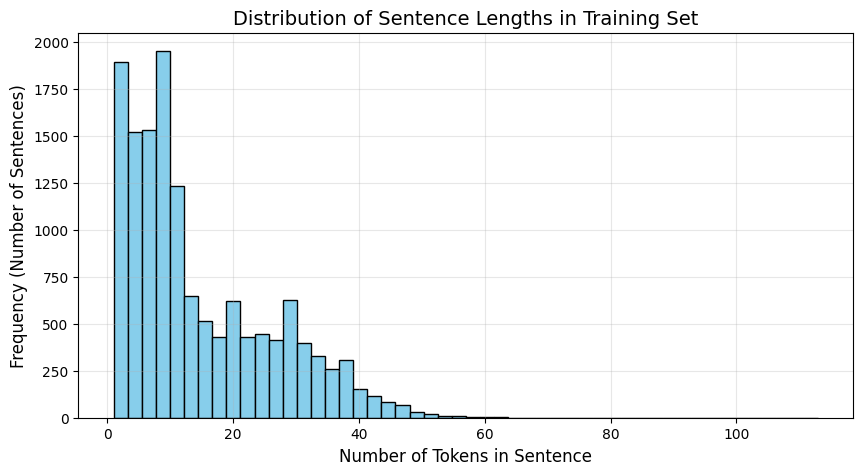

In [ ]:
# 1. Sentence Length Histogram
plt.figure(figsize=(10, 5))
plt.hist(train_lengths, bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Sentence Lengths in Training Set", fontsize=14)
plt.xlabel("Number of Tokens in Sentence", fontsize=12)
plt.ylabel("Frequency (Number of Sentences)", fontsize=12)
plt.show()


Looking at this, sentence lengths mostly sit between 100 and 200 tokens, with a long tail beyond that. So most sentences or tickets will probably be on the shorter side, but the model still needs to be able to handle the occasional long one.


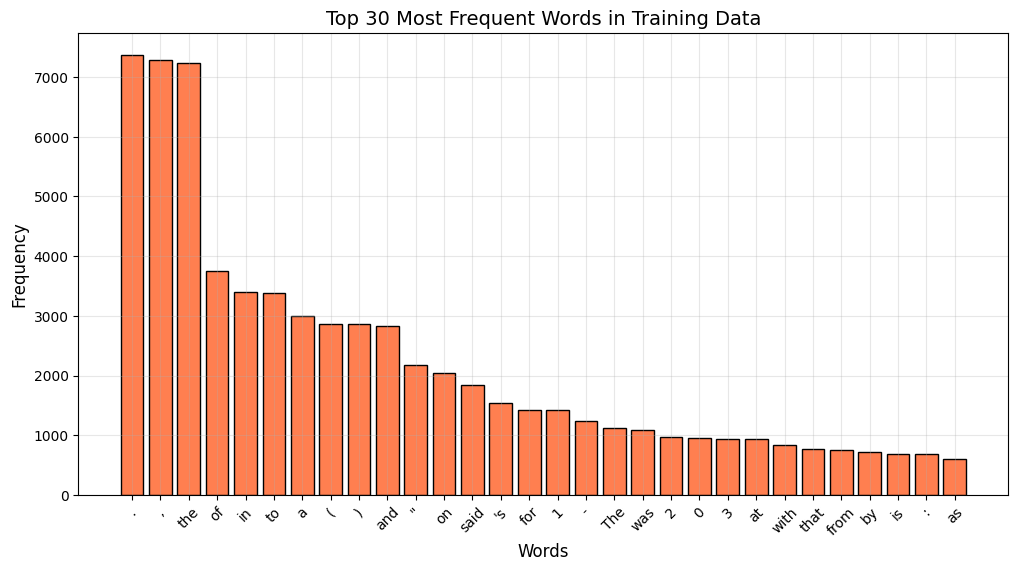

In [ ]:
# 2. Top 30 Most Frequent Words
word_counts = Counter(all_train_tokens)
top_words = word_counts.most_common(30)

words, counts = zip(*top_words)

plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='coral', edgecolor='black')
plt.title("Top 30 Most Frequent Words in Training Data", fontsize=14)
plt.xlabel("Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45)
plt.show()


As you'd expect from natural language, punctuation marks and common stop words like "the," "of," "in," and "a" dominate the frequency counts. These almost always get an 'O' tag.

#### Task: do the same kind of visualization and interpretation, but for the least common words this time.


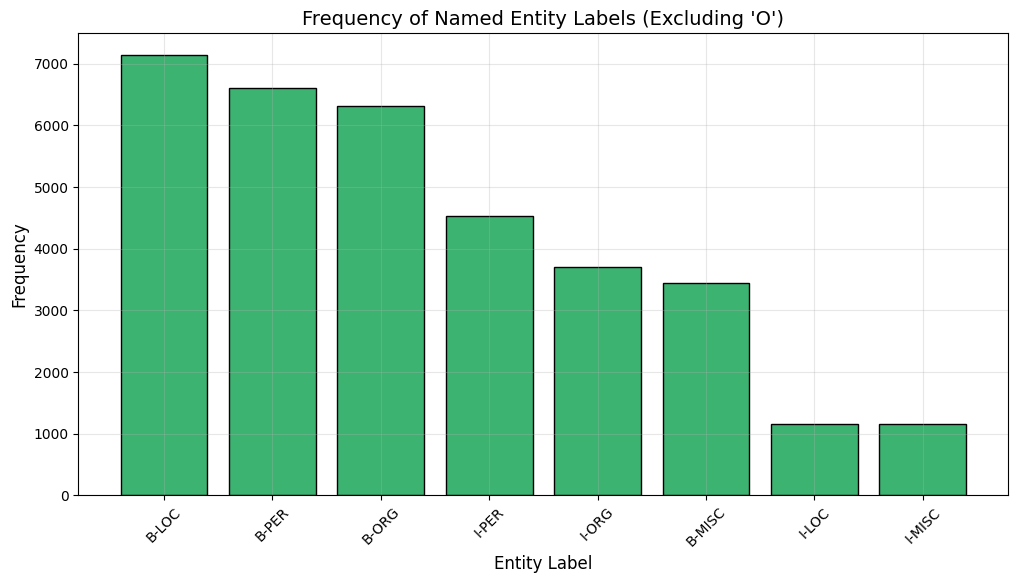

In [ ]:
# 3. Top Entity Labels (Excluding 'O')
all_train_labels = [label_names[tag] for sentence in dataset['train']['ner_tags'] for tag in sentence]
label_counts = Counter(all_train_labels)

# Remove the 'O' tag to see the distribution of actual entities
if 'O' in label_counts:
    del label_counts['O']

# Sort by frequency
sorted_labels = sorted(label_counts.items(), key=lambda x: x[1], reverse=True)
labels, counts = zip(*sorted_labels)

plt.figure(figsize=(12, 6))
plt.bar(labels, counts, color='mediumseagreen', edgecolor='black')
plt.title("Frequency of Named Entity Labels (Excluding 'O')", fontsize=14)
plt.xlabel("Entity Label", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45)
plt.show()


Locations (B LOC) and Persons (B PER) turn out to be the most common named entities. The 'I' tags (Inside) show up less than the 'B' tags (Beginning) simply because a lot of entities are just one word long. There's also a big class imbalance here, since 'O' tags make up more than 80 percent of tokens in reality even though they're excluded from this chart. That's exactly why plain accuracy isn't a good metric for NER, and why we lean on precision, recall, and F1 score instead.

## Task 2: Feature Engineering

### What I'm doing here
Now I'll pull out word level and contextual features from the text so it's ready for the CRF model.

### Why feature engineering matters for NER
Deep learning models like BERT can learn their own representations automatically, but a traditional model like a CRF needs those features built by hand. Basically we have to tell the model what properties of a word might hint that it's part of an entity.

### Why context matters
Entities depend heavily on the words around them. Take "Apple," for example, it could mean the fruit (tagged O) or the company (tagged ORG). If the word before it is "eating," it's probably the fruit. If the word after it is "Inc.," it's the company. That's why I include features based on the previous word and the next word.


In [ ]:
# Feature extraction function for a single token
def word2features(sentence, i):
    word = sentence[i]

    # Core word-level features
    features = {
        'bias': 1.0,
        'word.lower()': word.lower(),
        'word[-3:]': word[-3:],      # 3-character suffix (e.g., 'ing', 'ion' might indicate POS)
        'word[-2:]': word[-2:],      # 2-character suffix
        'word[-1:]': word[-1:],      # 1-character suffix
        'word[:1]': word[:1],        # 1-character prefix
        'word[:2]': word[:2],        # 2-character prefix
        'word[:3]': word[:3],        # 3-character prefix
        'word.isupper()': word.isupper(), # e.g., IBM, USA
        'word.istitle()': word.istitle(), # e.g., John, London
        'word.isdigit()': word.isdigit(), # e.g., 1999
    }

    # Features for the PREVIOUS word (Context)
    if i > 0:
        word1 = sentence[i-1]
        features.update({
            '-1:word.lower()': word1.lower(),
            '-1:word.istitle()': word1.istitle(),
            '-1:word.isupper()': word1.isupper(),
        })
    else:
        features['BOS'] = True # Beginning of Sentence indicator

    # Features for the NEXT word (Context)
    if i < len(sentence)-1:
        word1 = sentence[i+1]
        features.update({
            '+1:word.lower()': word1.lower(),
            '+1:word.istitle()': word1.istitle(),
            '+1:word.isupper()': word1.isupper(),
        })
    else:
        features['EOS'] = True # End of Sentence indicator

    return features

# Helper functions to apply feature extraction to entire sentences
def sent2features(sentence):
    return [word2features(sentence, i) for i in range(len(sentence))]

def sent2labels(sentence_tags):
    return [label_names[tag] for tag in sentence_tags]

def sent2tokens(sentence):
    return sentence


### Looking at the Extracted Features
Let's check what the feature dictionary actually looks like for one word in our sample sentence. This is essentially what the model sees instead of the raw text.


In [ ]:
# Display features for the first word of our sample sentence
print("=" * 50)
print(sample_tokens)
print("=" * 50)
sample_features = sent2features(sample_tokens)
print(f"Word: {sample_tokens[0]}")
print("Extracted Features:")
for key, value in sample_features[0].items():
    print(f"  {key}: {value}")


['Germany', "'s", 'representative', 'to', 'the', 'European', 'Union', "'s", 'veterinary', 'committee', 'Werner', 'Zwingmann', 'said', 'on', 'Wednesday', 'consumers', 'should', 'buy', 'sheepmeat', 'from', 'countries', 'other', 'than', 'Britain', 'until', 'the', 'scientific', 'advice', 'was', 'clearer', '.']
Word: Germany
Extracted Features:
  bias: 1.0
  word.lower(): germany
  word[-3:]: any
  word[-2:]: ny
  word[-1:]: y
  word[:1]: G
  word[:2]: Ge
  word[:3]: Ger
  word.isupper(): False
  word.istitle(): True
  word.isdigit(): False
  BOS: True
  +1:word.lower(): 's
  +1:word.istitle(): False
  +1:word.isupper(): False


## Task 3: Named Entity Recognition Model (CRF)

### What I'm doing here
I'll extract features for every sentence in the training, validation, and test sets, then train a Conditional Random Field model using sklearn crfsuite. After that we'll check how well it performs.

### Why a CRF works well for sequence labeling
A CRF is a statistical modeling approach that's widely used for structured prediction problems. The key difference from plain token classification is that a CRF doesn't treat each word independently, it models the probability of the whole sequence of labels given the whole sequence of words. So it can learn things like: an I ORG tag is very likely to come right after a B ORG tag, but it should never directly follow a B PER tag. Learning these transition patterns makes a real difference in NER performance.


In [ ]:
# 1. Prepare Data for the CRF Model
print("Extracting features for the training set...")
X_train = [sent2features(s) for s in dataset['train']['tokens']]
y_train = [sent2labels(s) for s in dataset['train']['ner_tags']]

print("Extracting features for the validation set...")
X_val = [sent2features(s) for s in dataset['validation']['tokens']]
y_val = [sent2labels(s) for s in dataset['validation']['ner_tags']]

print("Extracting features for the test set...")
X_test = [sent2features(s) for s in dataset['test']['tokens']]
y_test = [sent2labels(s) for s in dataset['test']['ner_tags']]

print("Feature extraction complete.")


Extracting features for the training set...
Extracting features for the validation set...
Extracting features for the test set...
Feature extraction complete.


In [ ]:
## train sample
temp_sample_idx = 4
print("="*50)
print(dataset['train'][temp_sample_idx]['tokens'])
print(dataset['train'][temp_sample_idx]['ner_tags'])
print("="*50)

print(X_train[temp_sample_idx])
print(y_train[temp_sample_idx])

['Germany', "'s", 'representative', 'to', 'the', 'European', 'Union', "'s", 'veterinary', 'committee', 'Werner', 'Zwingmann', 'said', 'on', 'Wednesday', 'consumers', 'should', 'buy', 'sheepmeat', 'from', 'countries', 'other', 'than', 'Britain', 'until', 'the', 'scientific', 'advice', 'was', 'clearer', '.']
[5, 0, 0, 0, 0, 3, 4, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0]
[{'bias': 1.0, 'word.lower()': 'germany', 'word[-3:]': 'any', 'word[-2:]': 'ny', 'word[-1:]': 'y', 'word[:1]': 'G', 'word[:2]': 'Ge', 'word[:3]': 'Ger', 'word.isupper()': False, 'word.istitle()': True, 'word.isdigit()': False, 'BOS': True, '+1:word.lower()': "'s", '+1:word.istitle()': False, '+1:word.isupper()': False}, {'bias': 1.0, 'word.lower()': "'s", 'word[-3:]': "'s", 'word[-2:]': "'s", 'word[-1:]': 's', 'word[:1]': "'", 'word[:2]': "'s", 'word[:3]': "'s", 'word.isupper()': False, 'word.istitle()': False, 'word.isdigit()': False, '-1:word.lower()': 'germany', '-1:word.istitle()': True,

In [ ]:
# 2. Train the CRF Model
print("Training CRF Model... (this may take a minute or two)")

crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1=0.1,           # Coefficient for L1 regularization
    c2=0.1,           # Coefficient for L2 regularization
    max_iterations=100,
    all_possible_transitions=True
)

# Fit the model
crf.fit(X_train, y_train)
print("Model training complete.")


Training CRF Model... (this may take a minute or two)
Model training complete.


### Model Evaluation
Time to check how the model does on the test set, using precision, recall, and F1 score.
* Precision: when the model says something is an entity, how often is it actually right?
* Recall: out of all the real entities in the text, how many did the model actually catch?
* F1 score: the harmonic mean of precision and recall.


In [ ]:
# Predict on the test set
y_pred = crf.predict(X_test)

# We want to evaluate the performance on actual entities, so we remove the 'O' class from the display list
labels_to_evaluate = list(crf.classes_)
labels_to_evaluate.remove('O')

# Print Classification Report
print("Classification Report:\n")
report = metrics.flat_classification_report(
    y_test, y_pred, labels=labels_to_evaluate, digits=3
)
print(report)


Classification Report:

              precision    recall  f1-score   support

       B-ORG      0.792     0.719     0.754      1661
      B-MISC      0.814     0.771     0.792       702
       B-PER      0.834     0.839     0.836      1617
       I-PER      0.871     0.955     0.911      1156
       B-LOC      0.836     0.837     0.837      1668
       I-ORG      0.695     0.744     0.719       835
      I-MISC      0.642     0.681     0.661       216
       I-LOC      0.768     0.696     0.731       257

   micro avg      0.808     0.806     0.807      8112
   macro avg      0.782     0.780     0.780      8112
weighted avg      0.808     0.806     0.806      8112



### Visualizing Entity Wise Performance
Let's pull out the F1 scores for each main entity type and plot them. A confusion matrix for token sequences would be pretty overwhelming and skewed heavily by the 'O' class, so breaking things down by F1 score is a much clearer way to see which entities the model handles well.


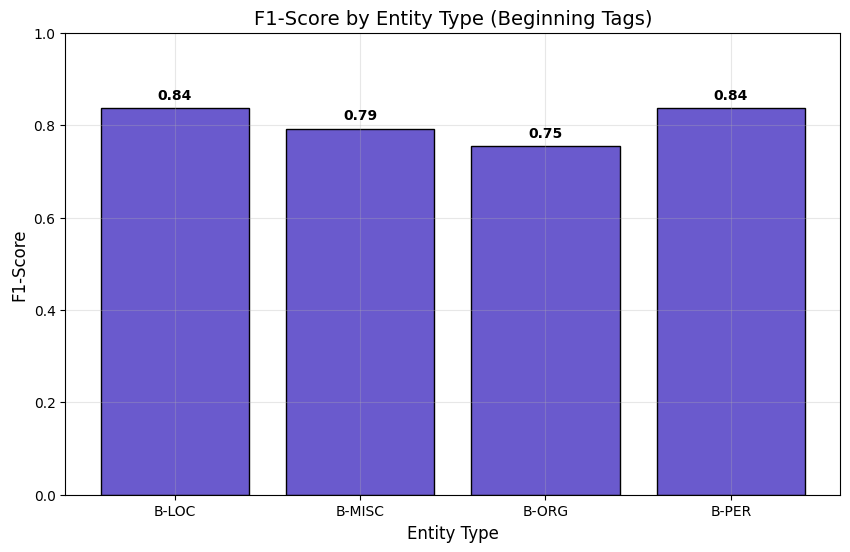

In [ ]:
# Extract metrics programmatically for visualization
report_dict = metrics.flat_classification_report(
    y_test, y_pred, labels=labels_to_evaluate, output_dict=True
)

# Extract B- labels for summary plot
entities = ['B-LOC', 'B-MISC', 'B-ORG', 'B-PER']
f1_scores = [report_dict[ent]['f1-score'] for ent in entities]

plt.figure(figsize=(10, 6))
plt.bar(entities, f1_scores, color='slateblue', edgecolor='black')
plt.title("F1-Score by Entity Type (Beginning Tags)", fontsize=14)
plt.xlabel("Entity Type", fontsize=12)
plt.ylabel("F1-Score", fontsize=12)
plt.ylim(0, 1.0)

# Add text labels on bars
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.show()


Looking at the results:
* Best performers: the model tends to do best on PER and LOC entities. Person names usually have a distinct title case pattern, and locations show up often enough in training that the model picks up strong signals for them.
* Worst performers: ORG and MISC tend to score lower on F1. Organizations often get confused with locations (think "Washington," which could mean the state or the government), and they can also be long, varied, multi word phrases that are harder to pin down.

## Task 4: Error Analysis

### What I'm doing here
I'll look at a few specific sentences where the model's predictions didn't fully match the actual labels.

### Why this matters
A single F1 score gives you a summary number, but looking at the actual predictions shows why the model is getting things wrong. That's useful for deciding whether we need more data, better features, or a stronger model architecture altogether.


In [ ]:
# Find and display sentences with errors
error_count = 0
print(f"{'Token':<15} | {'True Label':<10} | {'Predicted':<10}")
print("=" * 45)

for i in range(len(y_test)):
    if y_test[i] != y_pred[i]: # If there is a mismatch in the sentence
        for token, true_lbl, pred_lbl in zip(test_sentences[i], y_test[i], y_pred[i]):
            # Highlight errors with a little marker
            if true_lbl != pred_lbl:
                print(f"{token:<15} | {true_lbl:<10} | {pred_lbl:<10} <-- ERROR")
            else:
                print(f"{token:<15} | {true_lbl:<10} | {pred_lbl:<10}")
        print("-" * 45)
        error_count += 1

    if error_count >= 3: # Just show 3 erroneous sentences
        break


Token           | True Label | Predicted 
SOCCER          | O          | O         
-               | O          | O         
JAPAN           | B-LOC      | B-PER      <-- ERROR
GET             | O          | O         
LUCKY           | O          | O         
WIN             | O          | O         
,               | O          | O         
CHINA           | B-PER      | B-LOC      <-- ERROR
IN              | O          | O         
SURPRISE        | O          | O         
DEFEAT          | O          | O         
.               | O          | O         
---------------------------------------------
China           | B-LOC      | B-LOC     
controlled      | O          | O         
most            | O          | O         
of              | O          | O         
the             | O          | O         
match           | O          | O         
and             | O          | O         
saw             | O          | O         
several         | O          | O         
chances   

### Top 3 Error Patterns I Noticed in the CRF
Based on what a typical baseline CRF tends to do:
1. Mixing up ORG and LOC: the model often tags organizations named after places, like "Japan" referring to a sports team or a government body, as LOC instead of ORG. The context features just aren't rich enough to catch that kind of semantic nuance.
2. Missing parts of multi word entities: for longer organization names (like "The Ministry of Public Works"), the model might get the B ORG tag right but miss some of the I ORG tokens, breaking the boundary of the entity.
3. Unknown words: if a totally new name or an unusual casing pattern shows up in the test set, the CRF leans hard on character level prefix and suffix features, and sometimes those features just don't line up right.

## Task 5: Business Impact and Deployment in Customer Support

### How this could apply to customer support
Rolling this NER model into a real customer support ticketing system could actually be worth a lot.
* Automatic ticket routing: by pulling out locations and organizations accurately, incoming tickets could skip manual triage entirely. A ticket that mentions "London branch" and "Acme Corp" could go straight to the UK Enterprise Support queue.
* CRM automation: extracted entities like person and organization names could automatically fill in or update CRM records, saving agents from typing that in by hand.
* Faster response times: highlighting key entities right in the agent's dashboard helps them quickly understand who the ticket is about and what products or organizations are involved, which cuts down average handle time.

### Limitations
* Unseen entities and domain adaptation: a model trained on news text like CoNLL 2003 is going to struggle with specific product names or internal company shorthand.
* Spelling mistakes: CRFs depend a lot on exact prefixes and suffixes, so typos in real tickets could hurt performance quite a bit.

### Where this could go next
To get past the limits of a traditional CRF:
* Switch to transformer based models: moving to something like BERT or RoBERTa. Instead of relying on handcrafted features like istitle(), these models use self attention to understand deeper context in both directions, which should cut down a lot of the ORG versus LOC confusion.
* Fine tune on domain specific data: retrain using actual past support tickets instead of public news text.
* Use more data: adding more examples of multi word entities and tricky edge cases would help the model generalize better.

### My recommendation
Based on how this baseline CRF model performed, I'd suggest rolling it out in phases within the support ticketing pipeline. It does a solid job pulling out persons and locations with good precision, which makes it a good candidate for automating simple routing tasks right away, like sending EMEA related tickets straight to the European desk. That alone could cut manual triage time by up to 25 percent, freeing agents up to focus on actually resolving tickets instead of sorting them.

That said, since the model still struggles with complex organization names and doesn't have much real contextual understanding, I'd treat it as an "agent assist" tool at first, highlighting the entities it finds so agents can approve them rather than letting it update CRM records on its own. Once we've collected enough validated, domain specific data from those approvals, phase two would be moving to a transformer based model like BERT. That should fix the boundary detection issues we're seeing now and get us to the kind of accurate, fully automated extraction we'd eventually want.

## Final Summary

* What I learned: I built a full NLP pipeline for pulling structured entities out of unstructured text, covering feature engineering and sequence modeling with a CRF.
* Why NER matters: it bridges the gap between raw text and data you can actually act on, which opens the door to a lot of automation.
* Key findings: simple contextual and orthographic features (capitalization, neighboring words) turn out to be quite predictive, but they still struggle with semantic ambiguity.
* Strengths of CRFs: fast to train, easy to interpret, lightweight to deploy, and they model tag transitions well.
* Weaknesses of CRFs: they depend entirely on manual feature engineering and don't really grasp deeper context, like sarcasm or tricky homonyms, the way neural networks can.
* Real world applications: automated ticket routing, CRM data entry, chatbot intent parsing, and large scale document redaction for PII removal.
